# Project title:“What AI skills are most valuable in the job market?”
-Which AI skills are associated with higher salaries
-Which countries pay more for specific AI roles
-Whether the most discussed skills online are also the best paid
-Which skills seem undervalued or overhyped.

In [1]:
 import pandas as pd
df = pd.read_csv("ai_job_dataset.csv")
display(df)

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,AI14996,Robotics Engineer,38604,USD,EN,FL,Finland,S,Finland,50,"Java, Kubernetes, Azure",Bachelor,1,Energy,2025-02-06,2025-03-25,1635,7.9,Advanced Robotics
14996,AI14997,Machine Learning Researcher,57811,GBP,EN,CT,United Kingdom,M,United Kingdom,0,"Mathematics, Docker, SQL, Deep Learning",Master,0,Government,2024-10-16,2024-10-30,1624,8.2,Smart Analytics
14997,AI14998,NLP Engineer,189490,USD,EX,CT,South Korea,L,South Korea,50,"Scala, Spark, NLP",Associate,17,Manufacturing,2024-03-19,2024-05-02,1336,7.4,AI Innovations
14998,AI14999,Head of AI,79461,EUR,EN,FT,Netherlands,M,Netherlands,0,"Java, Computer Vision, Python, TensorFlow",PhD,1,Real Estate,2024-03-22,2024-04-23,1935,5.6,Smart Analytics


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_id                  15000 non-null  object 
 1   job_title               15000 non-null  object 
 2   salary_usd              15000 non-null  int64  
 3   salary_currency         15000 non-null  object 
 4   experience_level        15000 non-null  object 
 5   employment_type         15000 non-null  object 
 6   company_location        15000 non-null  object 
 7   company_size            15000 non-null  object 
 8   employee_residence      15000 non-null  object 
 9   remote_ratio            15000 non-null  int64  
 10  required_skills         15000 non-null  object 
 11  education_required      15000 non-null  object 
 12  years_experience        15000 non-null  int64  
 13  industry                15000 non-null  object 
 14  posting_date            15000 non-null

In [3]:
df.columns

Index(['job_id', 'job_title', 'salary_usd', 'salary_currency',
       'experience_level', 'employment_type', 'company_location',
       'company_size', 'employee_residence', 'remote_ratio', 'required_skills',
       'education_required', 'years_experience', 'industry', 'posting_date',
       'application_deadline', 'job_description_length', 'benefits_score',
       'company_name'],
      dtype='object')

In [4]:
df = df.drop(columns=[
    'job_id',
    'job_description_length',
    'company_name',
    'application_deadline',
    'posting_date'
])

In [5]:
df['salary_currency'].unique()

array(['USD', 'EUR', 'GBP'], dtype=object)

In [57]:
df["salary_currency"].value_counts()

salary_currency
USD    11957
EUR     2314
GBP      729
Name: count, dtype: int64

In [58]:
df["job_title"].value_counts()

job_title
Machine Learning Researcher    808
AI Software Engineer           784
Autonomous Systems Engineer    777
Machine Learning Engineer      772
AI Architect                   771
Head of AI                     765
NLP Engineer                   762
Robotics Engineer              759
Data Analyst                   759
AI Research Scientist          756
Data Engineer                  749
AI Product Manager             743
Research Scientist             742
Principal Data Scientist       734
AI Specialist                  728
ML Ops Engineer                725
Computer Vision Engineer       724
Data Scientist                 720
Deep Learning Engineer         718
AI Consultant                  704
Name: count, dtype: int64

In [8]:
currency_to_usd = {
    "USD": 1.0,
    "EUR": 1.1793,
    "GBP": 1.3569
}
df["salary_converted_usd"] = (
    pd.to_numeric(df["salary_usd"], errors="coerce")
    * df["salary_currency"].map(currency_to_usd)
).round(2)
df

,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,benefits_score,salary_converted_usd
0,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,5.9,90376.00
1,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,5.2,61895.00
2,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,9.4,152626.00
3,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,8.6,80215.00
4,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,6.6,64418.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,Robotics Engineer,38604,USD,EN,FL,Finland,S,Finland,50,"Java, Kubernetes, Azure",Bachelor,1,Energy,7.9,38604.00
14996,Machine Learning Researcher,57811,GBP,EN,CT,United Kingdom,M,United Kingdom,0,"Mathematics, Docker, SQL, Deep Learning",Master,0,Government,8.2,78443.75
14997,NLP Engineer,189490,USD,EX,CT,South Korea,L,South Korea,50,"Scala, Spark, NLP",Associate,17,Manufacturing,7.4,189490.00
14998,Head of AI,79461,EUR,EN,FT,Netherlands,M,Netherlands,0,"Java, Computer Vision, Python, TensorFlow",PhD,1,Real Estate,5.6,93708.36


In [65]:
#Which AI skills are associated with higher salaries?

import matplotlib.pyplot as plt

# 2. Basic cleaning

df["salary_converted_usd"] = pd.to_numeric(df["salary_converted_usd"], errors="coerce")

# 3. Define AI-specific skills

AI_SKILLS = {"NLP", "Deep Learning", "MLOps", "Computer Vision", "PyTorch","TensorFlow"}

# 4. Split and explode skills

df["skill_list"] = (df["required_skills"].astype(str).str.split(",").apply(lambda skills: [s.strip() for s in skills if s.strip()])
)

skills_df = df.explode("skill_list").rename(columns={"skill_list": "skill"})
skills_df["skill"] = skills_df["skill"].str.strip()


# 5. Classify each skill

skills_df["skill_group"] = skills_df["skill"].apply(lambda x: "AI-specific" if x in AI_SKILLS else "Supporting"
)

# 6. Overall salary baseline

overall_mean_salary = skills_df["salary_converted_usd"].mean()
overall_median_salary = skills_df["salary_converted_usd"].median()

# 7. Salary stats per skill

skill_salary_stats = (skills_df.groupby(["skill_group", "skill"]).agg(job_count=("salary_converted_usd", "count"),mean_salary_converted_usd=("salary_converted_usd", "mean"),median_salary_converted_usd=("salary_converted_usd", "median"),std_salary_converted_usd=("salary_converted_usd", "std")).reset_index())


# 8. Filter rare skills

MIN_JOB_COUNT = 30
skill_salary_filtered = skill_salary_stats[skill_salary_stats["job_count"] >= MIN_JOB_COUNT].copy()

# 9. Separate outputs

ai_skill_results = (skill_salary_filtered[skill_salary_filtered["skill_group"] == "AI-specific"].sort_values(by="median_salary_converted_usd", ascending=False))

supporting_skill_results = (skill_salary_filtered[skill_salary_filtered["skill_group"] == "Supporting"].sort_values(by="median_salary_converted_usd", ascending=False))


# 10. Print results

print("Overall mean salary in dataset: ${:,.2f}".format(overall_mean_salary))
print("Overall median salary in dataset: ${:,.2f}".format(overall_median_salary))

print("\nTop AI-specific skills by median salary:")
print(ai_skill_results[["skill", "job_count", "mean_salary_converted_usd", "median_salary_converted_usd"]].head(15))

print("\nTop supporting skills by median salary:")
print(supporting_skill_results[["skill", "job_count", "mean_salary_converted_usd", "median_salary_converted_usd"]].head(15))


# 11. Save results

#ai_skill_results.to_csv("q1_ai_specific_skill_salary.csv", index=False)
#supporting_skill_results.to_csv("q1_supporting_skill_salary.csv", index=False)
#skill_salary_filtered.to_csv("q1_all_skill_salary_split.csv", index=False)


Overall mean salary in dataset: $115,190.32
Overall median salary in dataset: $99,530.00

Top AI-specific skills by median salary:
             skill  job_count  mean_salary_converted_usd  \
3              NLP       2145              116217.931469   
2            MLOps       2164              115008.062384   
1    Deep Learning       2189              117242.074920   
4          PyTorch       2777              115527.204537   
0  Computer Vision       2284              115897.875219   
5       TensorFlow       3022              115143.438120   

   median_salary_converted_usd  
3                     101915.0  
2                     100992.5  
1                     100603.0  
4                     100002.0  
0                      99563.5  
5                      98893.5  

Top supporting skills by median salary:
                 skill  job_count  mean_salary_converted_usd  \
11                 Git       2631              116659.985177   
9               Docker       1862              1

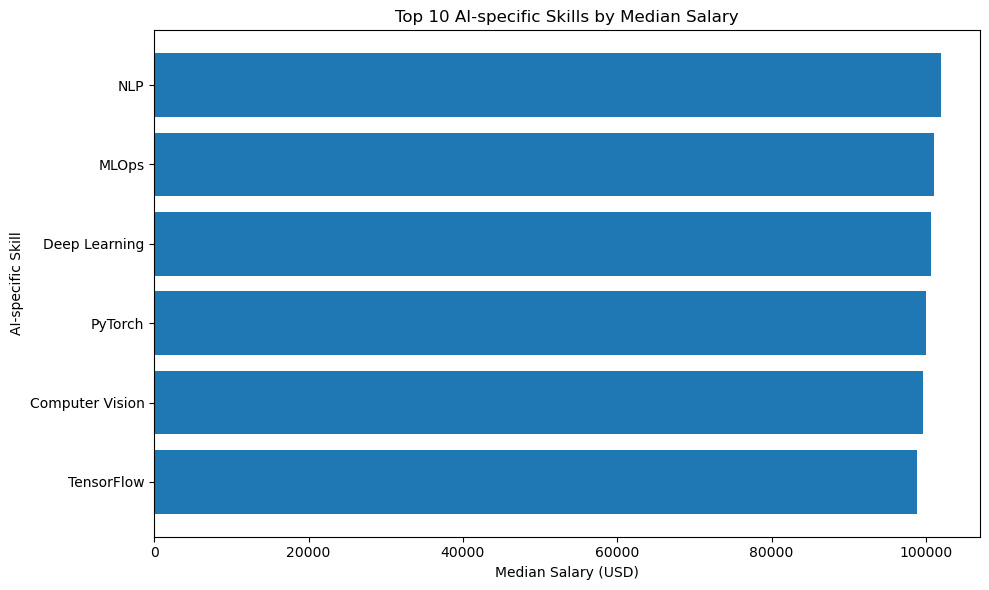

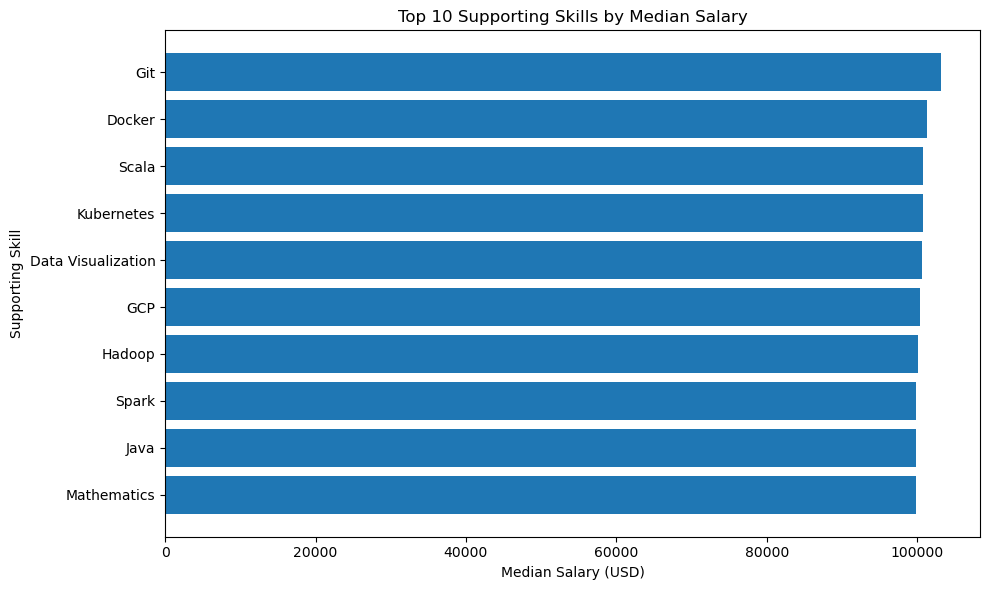

In [67]:
# 12. Plot top AI-specific skills

top_ai = ai_skill_results.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_ai["skill"], top_ai["median_salary_converted_usd"])
plt.xlabel("Median Salary (USD)")
plt.ylabel("AI-specific Skill")
plt.title("Top 10 AI-specific Skills by Median Salary")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# 13. Plot top supporting skills

top_supporting = supporting_skill_results.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_supporting["skill"], top_supporting["median_salary_converted_usd"])
plt.xlabel("Median Salary (USD)")
plt.ylabel("Supporting Skill")
plt.title("Top 10 Supporting Skills by Median Salary")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

The analysis shows that specialized AI skills are generally associated with higher salaries. Skills such as deep learning, NLP, MLOps, and frameworks like PyTorch and TensorFlow tend to command higher median salaries compared to more general or supporting skills.

This suggests that employers place a premium on advanced, technical expertise, particularly in areas that require deeper knowledge of machine learning systems and model deployment.


Top paying countries for each AI role:
       job_title_clean company_location  job_count  median_salary
306       ai architect      Switzerland         37       170735.0
342       ai architect    United States         41       160162.0
234       ai architect           Norway         33       155306.0
72        ai architect          Denmark         26       146013.0
0         ai architect        Australia         35       135021.0
..                 ...              ...        ...            ...
323  robotics engineer      Switzerland         36       146831.0
251  robotics engineer           Norway         25       140723.0
89   robotics engineer          Denmark         37       128576.0
269  robotics engineer        Singapore         38       127554.5
359  robotics engineer    United States         40       123557.5

[90 rows x 4 columns]


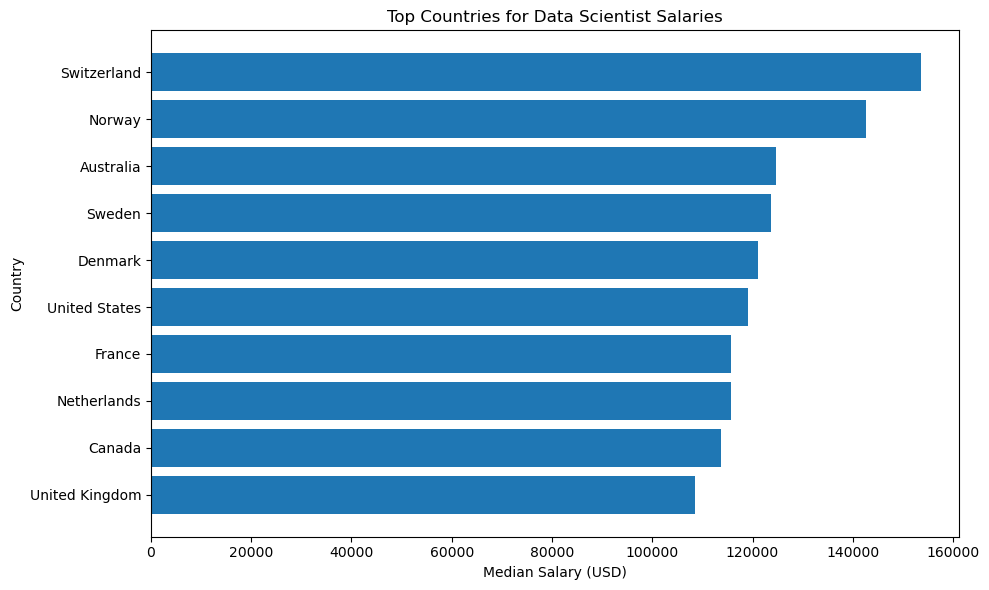

In [68]:
#Q2 which countries pay more for specefic AI roles?
#which countries pay more for specefic AI roles?
import pandas as pd
import matplotlib.pyplot as plt



# Clean salary column 
df["salary_converted_usd"] = pd.to_numeric(df["salary_converted_usd"], errors="coerce")


# Normalize job titles
df["job_title_clean"] = df["job_title"].str.lower()

# Define AI roles
AI_ROLES = ["Machine Learning Researcher","AI Software Engineer","Autonomous Systems Engineer","Machine Learning Engineer","AI Architect","Head of AI","NLP Engineer","Robotics Engineer","AI Research Scientist","AI Product Manager","Research Scientist","Principal Data Scientist","AI Specialist","ML Ops Engineer","Computer Vision Engineer","Data Scientist","Deep Learning Engineer","AI Consultant"]
AI_ROLES=[role.lower() for role in AI_ROLES]

# Filter AI roles
ai_df = df[
    df["job_title_clean"].apply(
        lambda x: any(role in x for role in AI_ROLES)
    )
]

# Group by country and role
country_role_salary = (
    ai_df
    .groupby(["company_location", "job_title_clean"])
    .agg(
        job_count=("salary_converted_usd", "count"),
        mean_salary=("salary_converted_usd", "mean"),
        median_salary=("salary_converted_usd", "median")
    )
    .reset_index()
)

# Filter low sample sizes
MIN_JOB_COUNT = 20
filtered = country_role_salary[
    country_role_salary["job_count"] >= MIN_JOB_COUNT
]

# Get top paying countries per role
top_paying = (
    filtered
    .sort_values(["job_title_clean", "median_salary"], ascending=[True, False])
    .groupby("job_title_clean")
    .head(5)
)

# Print results
print("\nTop paying countries for each AI role:")
print(top_paying[[
    "job_title_clean",
    "company_location",
    "job_count",
    "median_salary"
]])



# Plot role salaries by country for 4 roles
role = "data scientist"

role_data = (
    filtered[filtered["job_title_clean"] == role]
    .sort_values("median_salary", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.barh(role_data["company_location"], role_data["median_salary"])
plt.xlabel("Median Salary (USD)")
plt.ylabel("Country")
plt.title(f"Top Countries for {role.title()} Salaries")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

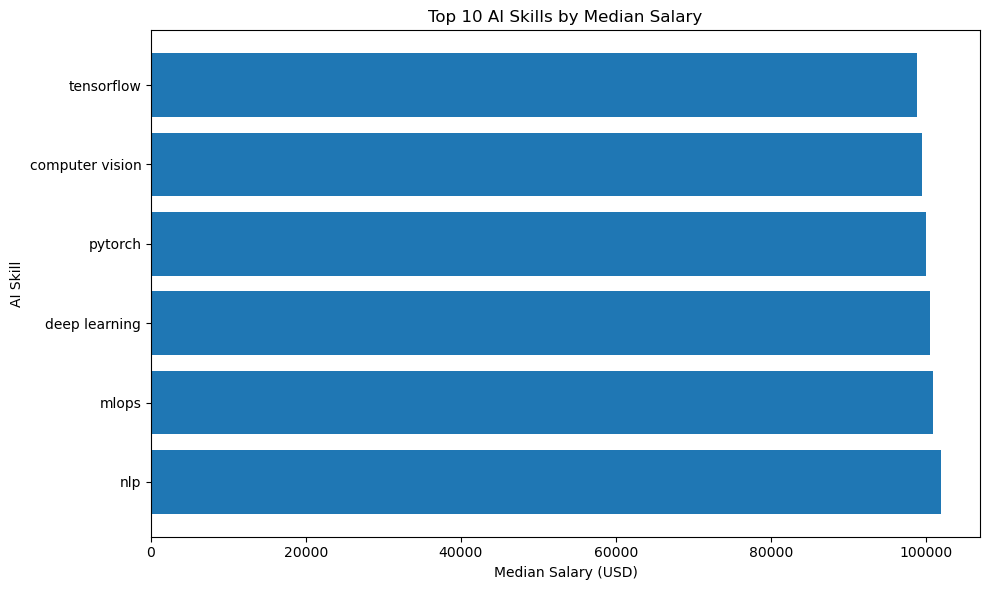

In [28]:
plt.figure(figsize=(10, 6))
plt.barh(top_ai["skill"], top_ai["median_salary_converted_usd"])

plt.xlabel("Median Salary (USD)")
plt.ylabel("AI Skill")
plt.title("Top 10 AI Skills by Median Salary")

plt.tight_layout()

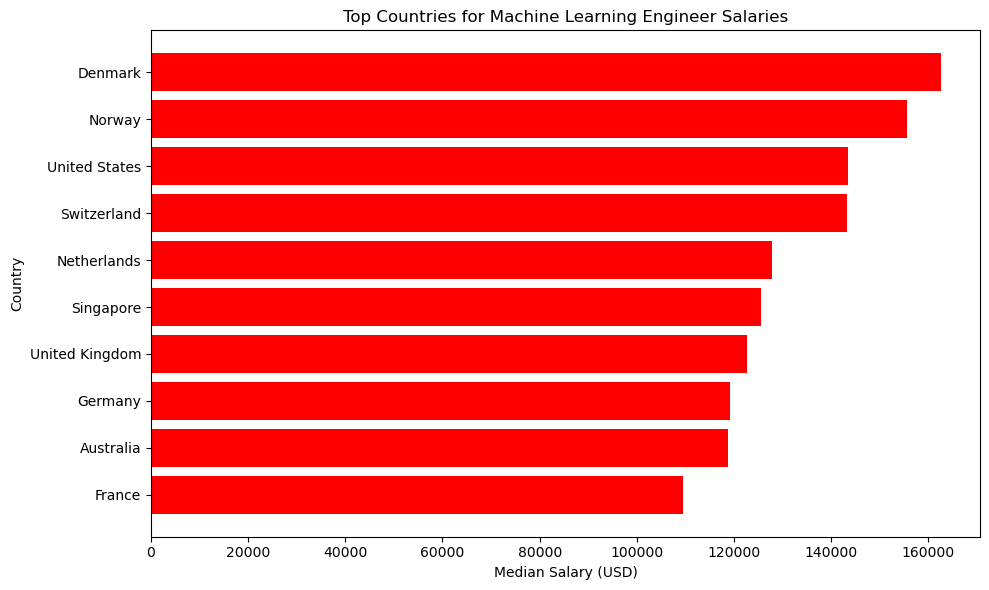

In [70]:
role = "machine learning engineer"

role_data = (
    filtered[filtered["job_title_clean"] == role]
    .sort_values("median_salary", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.barh(role_data["company_location"], role_data["median_salary"], color="red")
plt.xlabel("Median Salary (USD)")
plt.ylabel("Country")
plt.title(f"Top Countries for {role.title()} Salaries")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

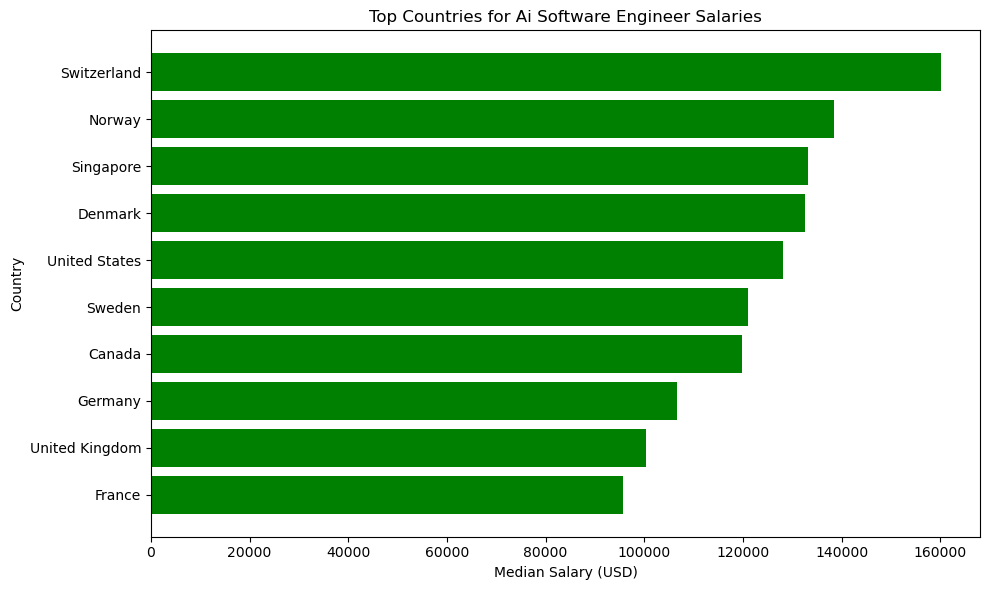

In [71]:
role = "ai software engineer"

role_data = (
    filtered[filtered["job_title_clean"] == role]
    .sort_values("median_salary", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.barh(role_data["company_location"], role_data["median_salary"], color="green")
plt.xlabel("Median Salary (USD)")
plt.ylabel("Country")
plt.title(f"Top Countries for {role.title()} Salaries")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

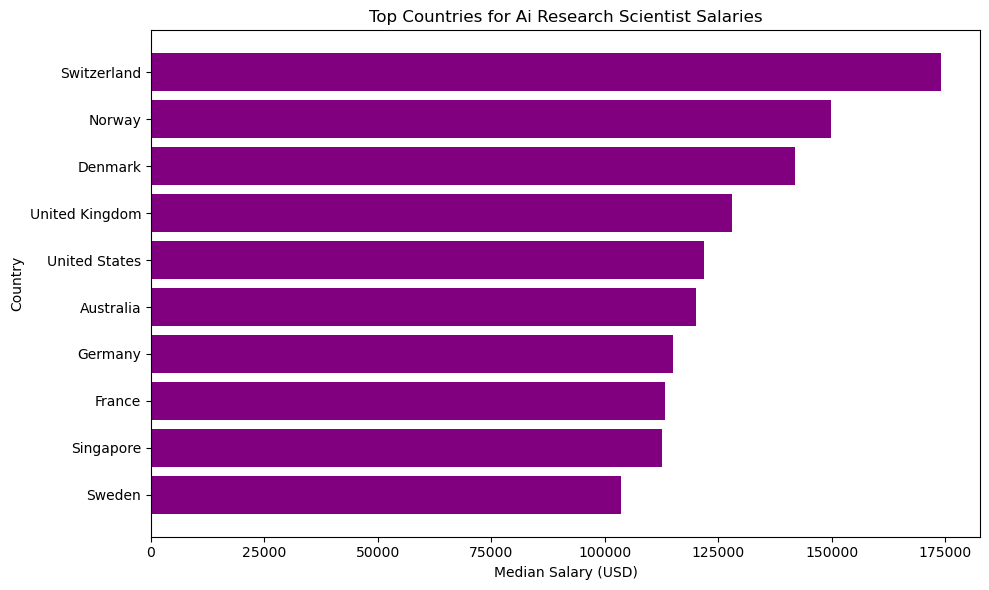

In [72]:
role = "ai research scientist"

role_data = (
    filtered[filtered["job_title_clean"] == role]
    .sort_values("median_salary", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.barh(role_data["company_location"], role_data["median_salary"], color="purple")
plt.xlabel("Median Salary (USD)")
plt.ylabel("Country")
plt.title(f"Top Countries for {role.title()} Salaries")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [73]:
#Q3-Whether the most discussed skills online are also the best paid?
# Q4-Which skills appear undervalued or overhyped?
import requests
import time
from datetime import datetime, timedelta, timezone

# 1. Keep only AI-specific skills from the dataset

df_q3 = skills_df.dropna(subset=["salary_converted_usd", "skill"]).copy()

df_q3 = df_q3[df_q3["skill"].isin(AI_SKILLS)].copy()


# 2. Salary stats for AI-specific skills

salary_stats = (
    df_q3.groupby("skill")
    .agg(
        job_count=("salary_converted_usd", "count"),
        mean_salary_usd=("salary_converted_usd", "mean"),
        median_salary_usd=("salary_converted_usd", "median")
    )
    .reset_index()
)

# 3. Map dataset skills to Stack Overflow tags

skill_to_tag = {
    "NLP": "nlp",
    "Deep Learning": "deep-learning",
    "MLOps": "mlops",
    "Computer Vision": "computer-vision",
    "PyTorch": "pytorch",
    "TensorFlow": "tensorflow"
}

# 4. Define time window: past 3 months

today = datetime.now(timezone.utc)
three_months_ago = today - timedelta(days=90)

FROM_DATE = int(three_months_ago.timestamp())
TO_DATE = int(today.timestamp())

# 5. Stack Exchange API helper

API_BASE = "https://api.stackexchange.com/2.3"
SITE = "stackoverflow"

def fetch_question_count_for_tag(tag, from_date, to_date):
    page = 1
    total_count = 0

    while True:
        params = {
            "site": SITE,
            "tagged": tag,
            "fromdate": from_date,
            "todate": to_date,
            "sort": "creation",
            "order": "desc",
            "pagesize": 100,
            "page": page
        }

        response = requests.get(f"{API_BASE}/questions", params=params, timeout=30)
        response.raise_for_status()
        data = response.json()

        items = data.get("items", [])
        total_count += len(items)

        if "backoff" in data:
            time.sleep(data["backoff"])

        if not data.get("has_more", False):
            break

        page += 1
        time.sleep(0.2)

    return total_count

# 6. Fetch discussion counts

discussion_rows = []

for skill, tag in skill_to_tag.items():
    try:
        question_count_3m = fetch_question_count_for_tag(tag, FROM_DATE, TO_DATE)
    except Exception as e:
        question_count_3m = None
        print(f"Error fetching {skill} ({tag}): {e}")

    discussion_rows.append({
        "skill": skill,
        "stack_tag": tag,
        "question_count_3m": question_count_3m
    })

discussion_df = pd.DataFrame(discussion_rows)

# 7. Merge salary data with discussion data

q3_df = salary_stats.merge(discussion_df, on="skill", how="left")

# 8. Compare rankings

q3_df["salary_rank"] = q3_df["median_salary_usd"].rank(ascending=False, method="dense")
q3_df["discussion_rank"] = q3_df["question_count_3m"].rank(ascending=False, method="dense")
q3_df["category"] = q3_df.apply(
    lambda row: "Overhyped" if row["discussion_rank"] < row["salary_rank"]
    else ("Undervalued" if row["discussion_rank"] > row["salary_rank"]
          else "Aligned"),
    axis=1
)

# Positive = more discussed than highly paid
# Negative = more highly paid than discussed
q3_df["rank_gap_discussion_minus_salary"] = (
    q3_df["discussion_rank"] - q3_df["salary_rank"]
)

# 10. Final result table

result_table = q3_df.sort_values("discussion_rank")[
    [
        "skill",
        "stack_tag",
        "job_count",
        "question_count_3m",
        "median_salary_usd",
        "salary_rank",
        "discussion_rank",
        "category"
    ]
]

display(result_table)

,skill,stack_tag,job_count,question_count_3m,median_salary_usd,salary_rank,discussion_rank,category
4,PyTorch,pytorch,2777,45,100002.0,4.0,1.0,Overhyped
5,TensorFlow,tensorflow,3022,25,98893.5,6.0,2.0,Overhyped
1,Deep Learning,deep-learning,2189,24,100603.0,3.0,3.0,Aligned
0,Computer Vision,computer-vision,2284,22,99563.5,5.0,4.0,Overhyped
3,NLP,nlp,2145,21,101915.0,1.0,5.0,Undervalued
2,MLOps,mlops,2164,1,100992.5,2.0,6.0,Undervalued


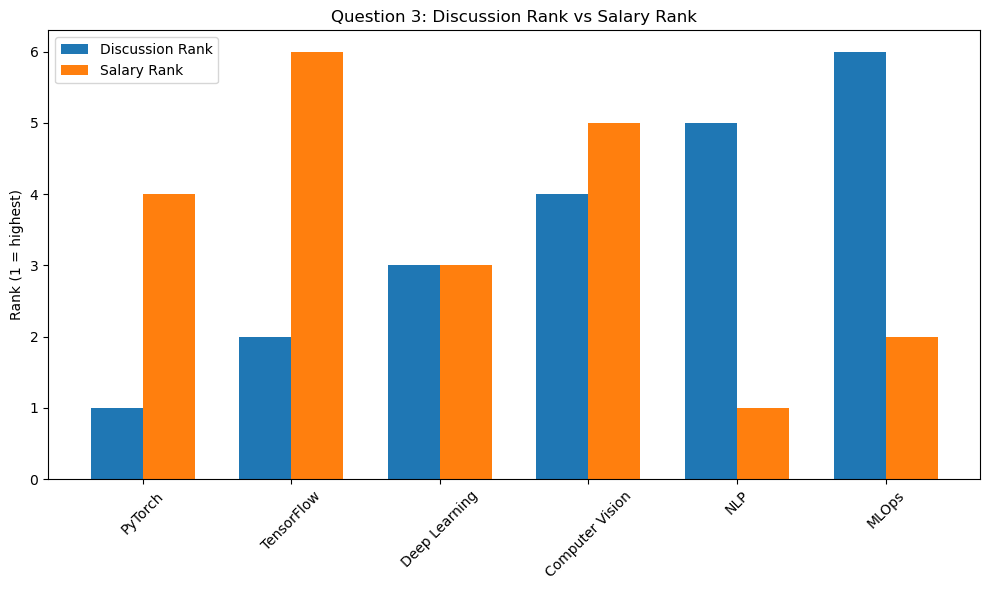

In [74]:
q3_plot = q3_df.sort_values("discussion_rank").copy()

x = range(len(q3_plot))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - width/2 for i in x], q3_plot["discussion_rank"], width=width, label="Discussion Rank")
plt.bar([i + width/2 for i in x], q3_plot["salary_rank"], width=width, label="Salary Rank")

plt.xticks(x, q3_plot["skill"], rotation=45)
plt.ylabel("Rank (1 = highest)")
plt.title("Question 3: Discussion Rank vs Salary Rank")
plt.legend()
plt.tight_layout()
plt.show()